# 1. EXPERIMENT 1 — PRETRAINED RESNET50



## 1.1 Load CIFAR-10 Dataset

We will use the complete CIFAR-10 dataset:

- 45,000 images for training
- 5,000 images for validation
- 10,000 images for testing

The validation split is created from the original training set using stratified sampling.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Original training data:", x_train.shape, y_train.shape)
print("Test data:", x_test.shape, y_test.shape)

TensorFlow: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Original training data: (50000, 32, 32, 3) (50000, 1)
Test data: (10000, 32, 32, 3) (10000, 1)


## 1.2 Create Training and Validation Splits

The original 50,000-image CIFAR-10 training set is divided into:

- 45,000 training images
- 5,000 validation images

Stratification preserves the class distribution across both subsets.

In [2]:
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training:", x_train_split.shape, y_train_split.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Training: (45000, 32, 32, 3) (45000, 1)
Validation: (5000, 32, 32, 3) (5000, 1)
Test: (10000, 32, 32, 3) (10000, 1)


## 1.3 CIFAR-10 Classes

CIFAR-10 contains 10 object categories.

In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1.4 Prepare CIFAR-10 for ResNet50

CIFAR-10 images are 32×32 pixels, whereas the pretrained ResNet50 backbone was originally designed for much larger ImageNet images.

For this hardware-adapted experiment, the images will be resized to 96×96 inside the model.

The preprocessing pipeline therefore becomes:

32×32×3
→ Resize
→ 96×96×3
→ ResNet preprocessing
→ ResNet50
→ 2048-dimensional feature vector
→ 10-class classifier

In [4]:
train_augmentation = keras.Sequential([
    keras.layers.Resizing(96, 96),
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
], name="train_augmentation")

val_preprocessing = keras.Sequential([
    keras.layers.Resizing(96, 96),
], name="val_preprocessing")

## 1.5 Load Pretrained ResNet50 Backbone

We use ResNet50 with ImageNet-pretrained weights.

The classification head is removed using:

include_top=False

Global average pooling converts the final convolutional feature maps into a 2048-dimensional feature vector.

In [5]:
resnet_base = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
    pooling="avg"
)

print("ResNet50 loaded successfully.")
print("Output shape:", resnet_base.output_shape)

ResNet50 loaded successfully.
Output shape: (None, 2048)


## 1.6 Build ResNet50 for CIFAR-10

The pretrained ImageNet classifier is replaced with a new 10-class CIFAR-10 classification head.

Data flow:

CIFAR-10 image
→ augmentation
→ ResNet preprocessing
→ pretrained ResNet50
→ 2048 features
→ Dense(10)
→ Softmax probabilities

In [6]:
inputs = keras.Input(shape=(32, 32, 3))

x = train_augmentation(inputs)

x = keras.applications.resnet.preprocess_input(x)

x = resnet_base(x)

outputs = keras.layers.Dense(
    10,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_CIFAR10"
)

model.summary()

Model: "ResNet50_CIFAR10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 train_augmentation (Sequent  (None, 96, 96, 3)        0         
 ial)                                                            
                                                                 
 tf.__operators__.getitem (S  (None, 96, 96, 3)        0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 96, 96, 3)        0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense (Dense)               (None, 10)           

## 1.7 Inspect Trainable and Non-Trainable Parameters

In [7]:
print("Total parameters:", model.count_params())

trainable_params = np.sum([
    np.prod(weight.shape)
    for weight in model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(weight.shape)
    for weight in model.non_trainable_weights
])

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 23608202
Trainable parameters: 23555082
Non-trainable parameters: 53120


In [8]:
assert model.count_params() == trainable_params + non_trainable_params

## 1.8 Compile the ResNet50 Model

The model is trained as a 10-class classifier using:

- Sparse Categorical Crossentropy — suitable for integer CIFAR-10 labels.
- Adam optimizer — adaptive gradient-based optimization.
- A small learning rate — appropriate because the ResNet50 backbone already contains pretrained ImageNet features.

All ResNet50 parameters remain trainable in this experiment.

In [9]:
loss = keras.losses.SparseCategoricalCrossentropy()

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 1.9 Configure the Training Run

The ResNet50 model will be trained using the complete 45,000-image CIFAR-10 training set.

Hardware-aware configuration:

- Training images: 45,000
- Validation images: 5,000
- Input resolution: 96×96
- GPU: NVIDIA GTX 1650 4 GB
- Initial batch size: 16
- Epochs: 1

A single epoch is used initially to measure the real GPU training throughput and memory behavior before committing to a longer training schedule.

In [10]:
batch_size = 16
epochs = 1

print("Training samples:", len(x_train_split))
print("Validation samples:", len(x_val))
print("Batch size:", batch_size)
print("Epochs:", epochs)

Training samples: 45000
Validation samples: 5000
Batch size: 16
Epochs: 1


## 1.10 Train ResNet50 on the Complete CIFAR-10 Dataset

The complete 45,000-image training set is used.

During training:

1. A batch of CIFAR-10 images enters the model.
2. Images are resized to 96×96.
3. Training augmentation is applied.
4. ResNet preprocessing is applied.
5. The pretrained ResNet50 performs the forward pass.
6. The 10-class prediction is compared with the true label.
7. Sparse categorical crossentropy produces the loss.
8. Gradients are calculated through the complete trainable network.
9. Adam updates the trainable parameters.
10. Validation performance is measured using the 5,000-image validation set.

In [11]:
history = model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

2813/2813 [==============================] - 361s 121ms/step - loss: 0.5271 - accuracy: 0.8232 - val_loss: 0.3658 - val_accuracy: 0.8764


## 1.11 Plot the Training History

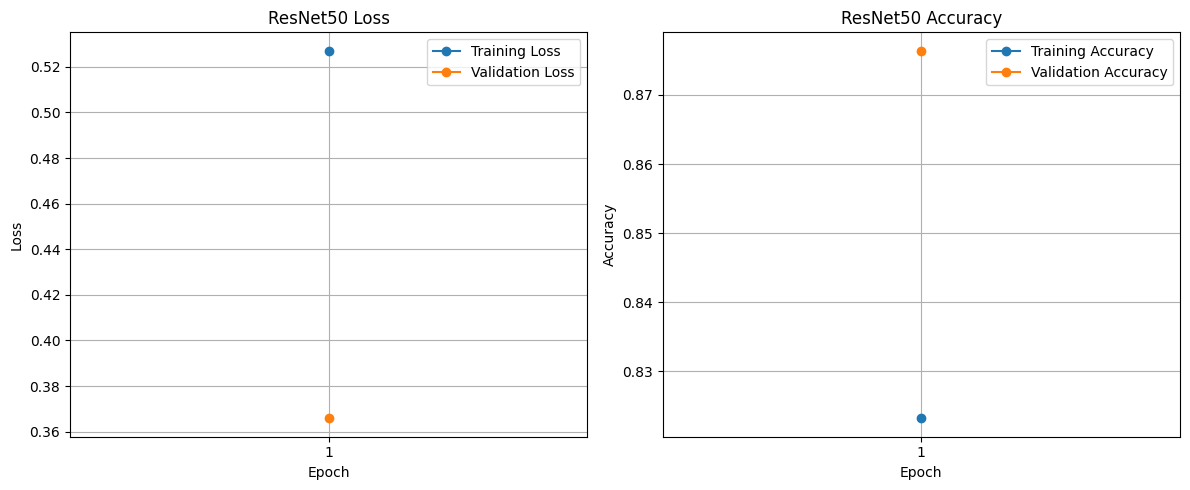

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.12 Evaluate ResNet50 on the CIFAR-10 Test Set

In [14]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    batch_size=batch_size,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

625/625 [==============================] - 17s 26ms/step - loss: 0.4227 - accuracy: 0.8747
Test loss: 0.4227
Test accuracy: 0.8747


## 1.13 Measure ResNet50 Inference Time and Model Size

In [15]:
import time
import os

# -----------------------------------
# 1. Warm-up inference
# -----------------------------------
_ = model.predict(
    x_test[:batch_size],
    batch_size=batch_size,
    verbose=0
)

# -----------------------------------
# 2. Measure inference time
# -----------------------------------
start_time = time.perf_counter()

predictions = model.predict(
    x_test,
    batch_size=batch_size,
    verbose=0
)

end_time = time.perf_counter()

inference_time = end_time - start_time
time_per_image = inference_time / len(x_test)
images_per_second = len(x_test) / inference_time

print(f"Total inference time: {inference_time:.2f} seconds")
print(f"Average time per image: {time_per_image * 1000:.2f} ms")
print(f"Inference throughput: {images_per_second:.2f} images/second")

# -----------------------------------
# 3. Save model and measure size
# -----------------------------------
model_path = "resnet50_cifar10_experiment1.h5"

model.save(model_path)

model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

print(f"Model size: {model_size_mb:.2f} MB")

Total inference time: 14.95 seconds
Average time per image: 1.50 ms
Inference throughput: 668.83 images/second
Model size: 270.57 MB


# 2. Experiment 2 — Feature Extraction

## 2.1 About Feature Extraction

```
     in Experiment 1 we used the ResNet50 weights but we allowed to train the weights of Resnet50 layers
     in this experiment we gonna freeze it and gonna only train the dense layer
     which gives 2048 output from it we gonna do the classifier of 10 
     we get logist scores from it
     using that we make the predictions out of it
```

## 2.2 Create a Fresh ImageNet-Pretrained ResNet50

In [16]:
feature_resnet_base = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3),
    pooling='avg'
    
)

In [17]:
# To verify the shapes
print(feature_resnet_base.input_shape)
print(feature_resnet_base.output_shape)
print(feature_resnet_base.count_params())

(None, 96, 96, 3)
(None, 2048)
23587712


## 2.3 Freeze the ResNet50 Backbone

In [18]:
feature_resnet_base.trainable = False

In [20]:
# we freezed the Resnet50's 23 Million paramenters now 
# we can use the values for predictions but we cannot change them 
# the dense layer is only trainable(the output layer which produced (None,2048))
# to verify that 

print(sum(tf.keras.backend.count_params(w)
         for w in feature_resnet_base.trainable_weights))

print(sum(tf.keras.backend.count_params(w)
         for w in feature_resnet_base.non_trainable_weights))

0
23587712


## 2.4 Build the Feature Extraction Model

In [21]:
inputs = keras.Input(shape=(32,32,3))

x = keras.layers.Resizing(96,96)(inputs)

x = keras.applications.resnet.preprocess_input(x)

x = feature_resnet_base(x)

outputs = keras.layers.Dense(
    10,
    activation= 'softmax'
)(x) 

feature_extraction_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_Feature_Extraction_CIFAR10"
)

In [22]:
feature_extraction_model.summary()

Model: "ResNet50_Feature_Extraction_CIFAR10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 resizing_2 (Resizing)       (None, 96, 96, 3)         0         
                                                                 
 tf.__operators__.getitem_1   (None, 96, 96, 3)        0         
 (SlicingOpLambda)                                               
                                                                 
 tf.nn.bias_add_1 (TFOpLambd  (None, 96, 96, 3)        0         
 a)                                                              
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_1 (Dense)             (N

## 2.5 Inspect Trainable and Non-Trainable Parameters

In [23]:
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in feature_extraction_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in feature_extraction_model.non_trainable_weights
)

total_params = trainable_params + non_trainable_params

print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters:         {total_params:,}")

# 20,490 coz dense produces 2048 each with 10 values so 2048 * 10 20480 + 10 bias so 20490 

Trainable parameters:     20,490
Non-trainable parameters: 23,587,712
Total parameters:         23,608,202


## 2.6 Compile the Feature Extraction Model

In [24]:
loss = keras.losses.SparseCategoricalCrossentropy()

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

feature_extraction_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

## 2.7 Train the Feature Extraction Model

In [25]:
batch_size = 16
epochs = 3

feature_history = feature_extraction_model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/3
2813/2813 [==============================] - 89s 30ms/step - loss: 0.8154 - accuracy: 0.7362 - val_loss: 0.5272 - val_accuracy: 0.8206
Epoch 2/3
2813/2813 [==============================] - 87s 31ms/step - loss: 0.4799 - accuracy: 0.8384 - val_loss: 0.4498 - val_accuracy: 0.8420
Epoch 3/3
2813/2813 [==============================] - 82s 29ms/step - loss: 0.4119 - accuracy: 0.8580 - val_loss: 0.4311 - val_accuracy: 0.8484


## 2.8 Plot Feature Extraction Training Curves

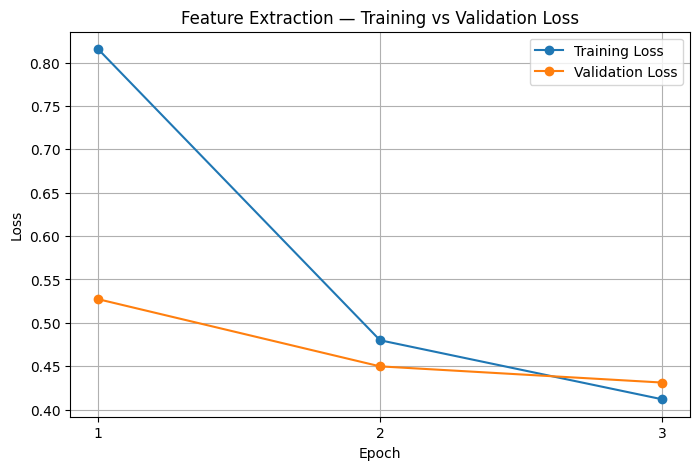

In [26]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(feature_history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    feature_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    feature_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Feature Extraction — Training vs Validation Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True)
plt.show()

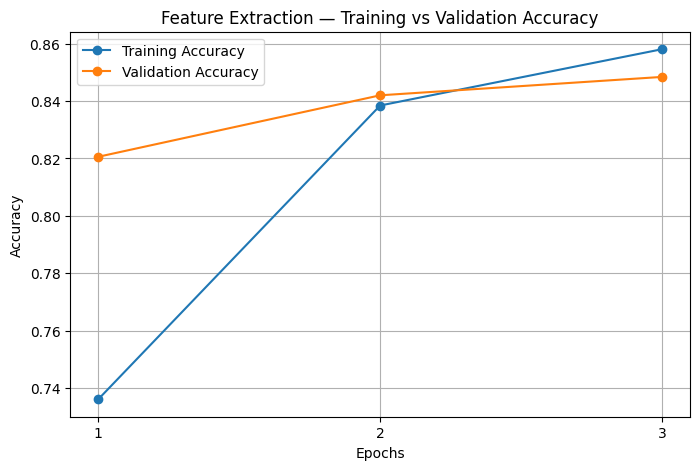

In [27]:
epochs_range = range(1,len(feature_history.history['loss']) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    feature_history.history['accuracy'],
    marker = 'o',
    label = 'Training Accuracy'
)

plt.plot(
    epochs_range,
    feature_history.history['val_accuracy'],
    marker = 'o',
    label = 'Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Feature Extraction — Training vs Validation Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True)
plt.show()

## 2.9 Evaluate Feature Extraction on the Test Set

In [28]:
test_loss_feature,test_accuracy_feature = feature_extraction_model.evaluate(
    x_test,
    y_test,
    batch_size= batch_size,
    verbose=1
)

print(f'Test Loss: {test_loss_feature:.2f}')
print(f'Test Accuracy: {test_accuracy_feature:.2f}')

625/625 [==============================] - 16s 26ms/step - loss: 0.4522 - accuracy: 0.8493
Test Loss: 0.45
Test Accuracy: 0.85


## 2.10 Benchmark Inference Time and Model Size

In [29]:
import time
import os

# Warm-up inference
_ = feature_extraction_model.predict(
    x_test[:batch_size],
    batch_size=batch_size,
    verbose=0
)

# Measure inference time on the complete test set
start_time = time.perf_counter()

feature_predictions = feature_extraction_model.predict(
    x_test,
    batch_size=batch_size,
    verbose=0
)

end_time = time.perf_counter()

inference_time_feature = end_time - start_time

time_per_image_feature = inference_time_feature / len(x_test)

images_per_second_feature = len(x_test) / inference_time_feature

print(f"Total inference time: {inference_time_feature:.2f} seconds")
print(f"Time per image:       {time_per_image_feature * 1000:.2f} ms")
print(f"Images per second:    {images_per_second_feature:.2f}")

Total inference time: 14.80 seconds
Time per image:       1.48 ms
Images per second:    675.86


In [30]:
feature_model_path = "resnet50_feature_extraction_cifar10.h5"

feature_extraction_model.save(feature_model_path)

feature_model_size_mb = (
    os.path.getsize(feature_model_path) / (1024 ** 2)
)

print(f"Model size: {feature_model_size_mb:.2f} MB")

Model size: 90.54 MB


| Metric                 | Experiment 1 — Full Fine Training | Experiment 2 — Feature Extraction |
| ---------------------- | --------------------------------: | --------------------------------: |
| Backbone               |                          ResNet50 |                          ResNet50 |
| Pretrained             |                          ImageNet |                          ImageNet |
| Backbone               |                      🔓 Trainable |                         🔒 Frozen |
| Trainable parameters   |                        23,555,082 |                        **20,490** |
| Test accuracy          |                        **87.47%** |                        **84.93%** |
| Test loss              |                            0.4227 |                            0.4522 |
| Inference / 10k images |                           14.95 s |                       **14.80 s** |
| Time / image           |                           1.50 ms |                       **1.48 ms** |
| Throughput             |                      668.83 img/s |                  **675.86 img/s** |
| Model size             |                         270.57 MB |                      **90.54 MB** |


# 3. Experiment 3 — Fine-Tuning

## 3.1 What Is Fine-Tuning?

```
Start with a pretrained model.
Freeze some layers so their learned features remain unchanged.
Unfreeze selected layers.
Train those layers together with the new classifier.
Usually use a small learning rate, because we're making small adjustments to already useful weights.
```

## 3.2 Create a Fresh ImageNet-Pretrained ResNet50

In [5]:
fine_tune_resnet_base = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
    pooling="avg"
)

print("Input shape:", fine_tune_resnet_base.input_shape)
print("Output shape:", fine_tune_resnet_base.output_shape)
print("Total parameters:", fine_tune_resnet_base.count_params())

Input shape: (None, 96, 96, 3)
Output shape: (None, 2048)
Total parameters: 23587712


## 3.3 Select Layers for Fine-Tuning

In [6]:
fine_tune_resnet_base.trainable = False

In [7]:
fine_tune_resnet_base.trainable = True

for layer in fine_tune_resnet_base.layers[:-30]:
    layer.trainable = False

for layer in fine_tune_resnet_base.layers[-30:]:
    layer.trainable = True

##  3.4 Build the Fine-Tuning Model

In [8]:
inputs = keras.Input(shape=(32, 32, 3))

x = keras.layers.Resizing(96, 96)(inputs)

x = keras.applications.resnet.preprocess_input(x)

x = fine_tune_resnet_base(x)

outputs = keras.layers.Dense(
    10,
    activation="softmax"
)(x)

fine_tuning_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_Fine_Tuning_CIFAR10"
)

## 3.5 Inspect Trainable Parameters

In [9]:
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in fine_tuning_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in fine_tuning_model.non_trainable_weights
)

total_params = trainable_params + non_trainable_params

print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters:         {total_params:,}")

Trainable parameters:     14,470,666
Non-trainable parameters: 9,137,536
Total parameters:         23,608,202


## 3.6 Compile the Fine-Tuning Model

In [10]:
loss = keras.losses.SparseCategoricalCrossentropy()

optimizer = keras.optimizers.Adam(
    learning_rate=1e-5
)

fine_tuning_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

## 3.7 Train the Fine-Tuning Model

In [11]:
batch_size = 16
epochs = 3

fine_tune_history = fine_tuning_model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/3
2813/2813 [==============================] - 144s 47ms/step - loss: 0.7772 - accuracy: 0.7418 - val_loss: 0.4236 - val_accuracy: 0.8552
Epoch 2/3
2813/2813 [==============================] - 131s 47ms/step - loss: 0.3555 - accuracy: 0.8792 - val_loss: 0.3472 - val_accuracy: 0.8852
Epoch 3/3
2813/2813 [==============================] - 132s 47ms/step - loss: 0.2225 - accuracy: 0.9270 - val_loss: 0.3245 - val_accuracy: 0.8942


## 3.8 Plot Fine-Tuning Learning Curves

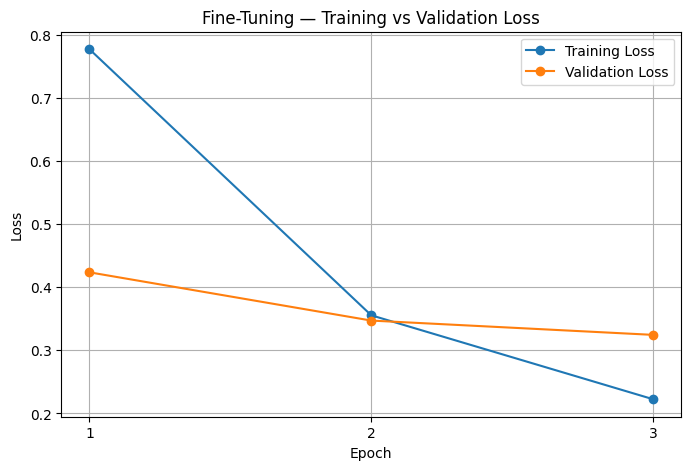

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(
    1,
    len(fine_tune_history.history["loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    fine_tune_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    fine_tune_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning — Training vs Validation Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True)
plt.show()

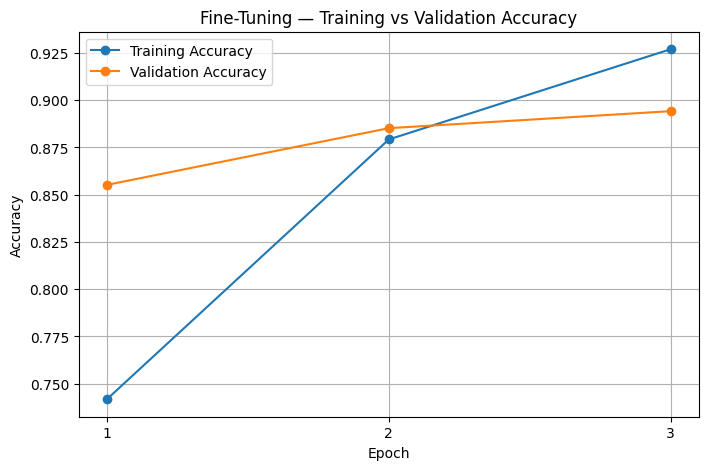

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    fine_tune_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    fine_tune_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning — Training vs Validation Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True)
plt.show()

##  3.9 Evaluate Fine-Tuning on the Test Set

In [14]:
test_loss_fine, test_accuracy_fine = fine_tuning_model.evaluate(
    x_test,
    y_test,
    batch_size=batch_size,
    verbose=1
)

print(f"Test Loss: {test_loss_fine:.4f}")
print(f"Test Accuracy: {test_accuracy_fine:.4%}")

625/625 [==============================] - 17s 26ms/step - loss: 0.3351 - accuracy: 0.8904
Test Loss: 0.3351
Test Accuracy: 89.0400%


## 3.10 Benchmark Inference Time

In [15]:
import time

# Warm-up
_ = fine_tuning_model.predict(
    x_test[:batch_size],
    batch_size=batch_size,
    verbose=0
)

start_time = time.perf_counter()

fine_predictions = fine_tuning_model.predict(
    x_test,
    batch_size=batch_size,
    verbose=0
)

end_time = time.perf_counter()

inference_time_fine = end_time - start_time
time_per_image_fine = inference_time_fine / len(x_test)
images_per_second_fine = len(x_test) / inference_time_fine

print(f"Total inference time: {inference_time_fine:.2f} seconds")
print(f"Time per image:       {time_per_image_fine * 1000:.2f} ms")
print(f"Images per second:    {images_per_second_fine:.2f}")

Total inference time: 15.34 seconds
Time per image:       1.53 ms
Images per second:    651.77


## 3.11 Benchmark Model Size

In [16]:
import os

fine_model_path = "resnet50_fine_tuning_cifar10.h5"

fine_tuning_model.save(fine_model_path)

fine_model_size_mb = (
    os.path.getsize(fine_model_path) / (1024 ** 2)
)

print(f"Model size: {fine_model_size_mb:.2f} MB")

Model size: 200.86 MB


| Metric               | Experiment 1 — Full Training | Experiment 2 — Feature Extraction | Experiment 3 — Fine-Tuning |
| -------------------- | ---------------------------: | --------------------------------: | -------------------------: |
| Backbone             |           🔓 Fully trainable |                   🔒 Fully frozen |  🔒/🔓 Partially trainable |
| Trainable parameters |               **23,555,082** |                        **20,490** |             **14,470,666** |
| Total parameters     |                   23,608,202 |                        23,608,202 |                 23,608,202 |
| Test accuracy        |                       87.47% |                            84.93% |                 **89.04%** |
| Test loss            |                       0.4227 |                            0.4522 |                 **0.3351** |
| Inference / 10k      |                      14.95 s |                           14.80 s |                    15.34 s |
| Time / image         |                      1.50 ms |                           1.48 ms |                    1.53 ms |
| Throughput           |                 668.83 img/s |                      675.86 img/s |               651.77 img/s |
| Model size           |                    270.57 MB |                          90.54 MB |                  200.86 MB |


# 4. Experiment 4 — EfficientNet

## 4.1 What Is EfficientNet?


```
Traditional CNN scaling often means choosing one thing to increase:

Make network deeper
        OR
Make network wider
        OR
Use larger input images

EfficientNet introduced a systematic way to scale all three together.

The three dimensions
                 CNN
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
    Depth       Width     Resolution
  more layers  more       larger
               channels   images

EfficientNet uses compound scaling:

Depth      ↗
Width      ↗      together
Resolution ↗

instead of arbitrarily increasing only one dimension.
```

## 4.2 EfficientNet Architecture


```
Input
  ↓
1×1 Expansion
  ↓
Depthwise Convolution
  ↓
Squeeze-and-Excitation
  ↓
1×1 Projection
  ↓
Residual connection
  ↓
Output

## 4.3 Which EfficientNet Are We Using?


```
For our experiment, we'll use:

EfficientNetB0

Why B0?

Because it is the baseline EfficientNet architecture and is considerably more practical on  GTX 1650 4 GB than jumping immediately to larger variants.

We'll keep the experiment comparable:

CIFAR-10
45,000 train
5,000 validation
10,000 test

and use ImageNet-pretrained weights.

## 4.4 Create ImageNet-Pretrained EfficientNetB0

In [17]:
efficientnet_base = keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
    pooling="avg"
)

print("Input shape:", efficientnet_base.input_shape)
print("Output shape:", efficientnet_base.output_shape)
print("Total parameters:", efficientnet_base.count_params())

16705208/16705208 [==============================] - 8s 1us/step
Input shape: (None, 96, 96, 3)
Output shape: (None, 1280)
Total parameters: 4049571


## 4.5 Inspect EfficientNetB0

In [18]:
efficientnet_base.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 rescaling (Rescaling)          (None, 96, 96, 3)    0           ['input_3[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 96, 96, 3)    7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 96, 96, 3)    0           ['normalization[0][0]']          
                                                                                     

## 4.6 Build the EfficientNet CIFAR-10 Model

In [19]:
efficientnet_base.trainable = False

In [20]:
inputs = keras.Input(shape=(32,32,3))

x = keras.layers.Resizing(96,96)(inputs)

x = efficientnet_base(x)

outputs = keras.layers.Dense(
    10,
    activation='softmax'
)(x)

efficientnet_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_CIFAR10"
)

## 4.7 Inspect EfficientNet Parameters

In [21]:
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in efficientnet_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in efficientnet_model.non_trainable_weights
)

total_params = trainable_params + non_trainable_params

print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters:         {total_params:,}")

Trainable parameters:     12,810
Non-trainable parameters: 4,049,571.0
Total parameters:         4,062,381.0


## 4.8 Compile the EfficientNet Model

In [23]:
loss = keras.losses.SparseCategoricalCrossentropy()

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

efficientnet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

## 4.9 Train the EfficientNet Model

In [24]:
batch_size = 16
epochs = 3

efficientnet_history = efficientnet_model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/3
2813/2813 [==============================] - 65s 20ms/step - loss: 0.9511 - accuracy: 0.7226 - val_loss: 0.5853 - val_accuracy: 0.8170
Epoch 2/3
2813/2813 [==============================] - 53s 19ms/step - loss: 0.5657 - accuracy: 0.8179 - val_loss: 0.4997 - val_accuracy: 0.8352
Epoch 3/3
2813/2813 [==============================] - 53s 19ms/step - loss: 0.5055 - accuracy: 0.8337 - val_loss: 0.4678 - val_accuracy: 0.8446


## 4.10 Plot EfficientNet Learning Curves

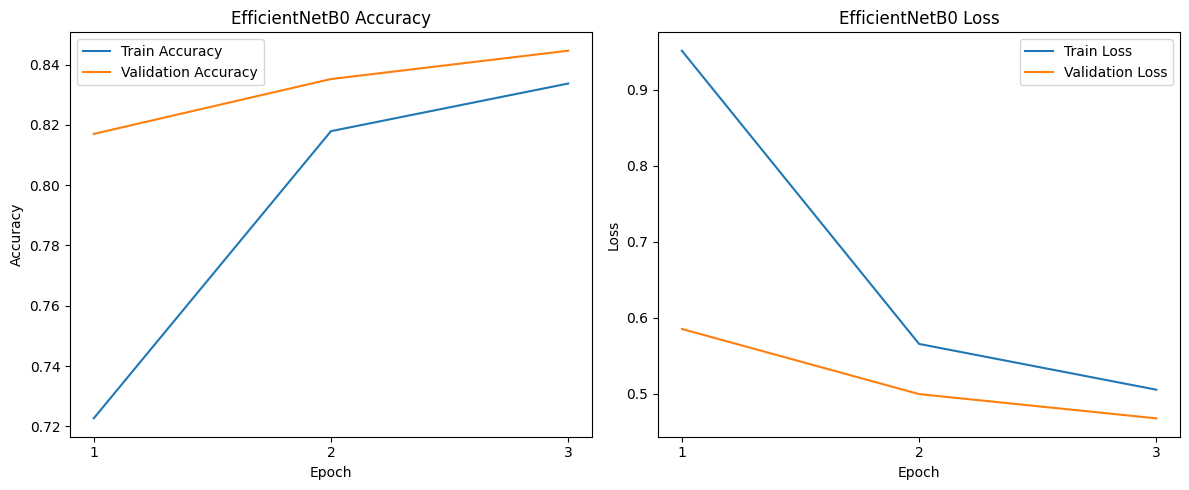

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
epochs_range = range(1,len(efficientnet_history.history['loss'])+1)
plt.subplot(1, 2, 1)
plt.plot(epochs_range,efficientnet_history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_range,efficientnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.title("EfficientNetB0 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range,efficientnet_history.history["loss"], label="Train Loss")
plt.plot(epochs_range,efficientnet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.title("EfficientNetB0 Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 4.11 Evaluate EfficientNet on the Test Set

In [30]:
efficientnet_test_loss, efficientnet_test_accuracy = efficientnet_model.evaluate(
    x_test,
    y_test,
    batch_size=16,
    verbose=1
)

print(f"EfficientNetB0 Test Loss:     {efficientnet_test_loss:.4f}")
print(f"EfficientNetB0 Test Accuracy: {efficientnet_test_accuracy * 100:.2f}%")

625/625 [==============================] - 11s 17ms/step - loss: 0.4852 - accuracy: 0.8403
EfficientNetB0 Test Loss:     0.4852
EfficientNetB0 Test Accuracy: 84.03%


## 4.12 Measure EfficientNet Inference Speed

In [31]:
import time

# warmup time 
_ = efficientnet_model.predict(
    x_test[:20],
    batch_size=16,
    verbose=1
)

start_time = time.time()

predictions = efficientnet_model.predict(
    x_test,
    batch_size=16,
    verbose=1
)

end_time = time.time()

total_time = end_time - start_time
num_images = len(x_test)

ms_per_image = (total_time / num_images) * 1000
images_per_second = num_images / total_time

print(f"Total inference time: {total_time:.2f} seconds")
print(f"Time per image:       {ms_per_image:.2f} ms")
print(f"Throughput:            {images_per_second:.2f} images/sec")

625/625 [==============================] - 9s 14ms/step
Total inference time: 9.38 seconds
Time per image:       0.94 ms
Throughput:            1066.32 images/sec


## 4.13 Measure EfficientNet Model Size

In [35]:
import numpy as np

total_weight_bytes = sum(
    weight.numpy().nbytes
    for weight in efficientnet_model.weights
)

model_size_mb = total_weight_bytes / (1024 ** 2)

print(f"EfficientNetB0 weight size: {model_size_mb:.2f} MB")

EfficientNetB0 weight size: 15.50 MB


In [48]:
import os

efficientnet_weights_path = "efficientnet_b0_cifar10.weights.h5"

efficientnet_model.save_weights(efficientnet_weights_path)

efficientnet_weights_size_mb = (
    os.path.getsize(efficientnet_weights_path) / (1024 ** 2)
)

print(f"EfficientNetB0 raw weight file size: {efficientnet_weights_size_mb:.2f} MB")

EfficientNetB0 raw weight file size: 15.76 MB


| Metric                    | **Exp 1 — ResNet50 Full Training** | **Exp 2 — ResNet50 Feature Extraction** | **Exp 3 — ResNet50 Fine-Tuning** | **Exp 4 — EfficientNetB0** |
| ------------------------- | ---------------------------------: | --------------------------------------: | -------------------------------: | -------------------------: |
| **Backbone**              |                           ResNet50 |                                ResNet50 |                         ResNet50 |             EfficientNetB0 |
| **Backbone state**        |                    Fully trainable |                            Fully frozen |         Last 30 layers trainable |                     Frozen |
| **Trainable parameters**  |                         23,555,082 |                                  20,490 |                       14,470,666 |                 **12,810** |
| **Total parameters**      |                         23,608,202 |                              23,608,202 |                       23,608,202 |              **4,062,381** |
| **Test accuracy**         |                             87.47% |                                  84.93% |                       **89.04%** |                     84.03% |
| **Test loss**             |                             0.4227 |                                  0.4522 |                       **0.3351** |                     0.4852 |
| **Inference / 10k**       |                            14.95 s |                                 14.80 s |                          15.34 s |                 **9.38 s** |
| **Time / image**          |                            1.50 ms |                                 1.48 ms |                          1.53 ms |                **0.94 ms** |
| **Throughput**            |                       668.83 img/s |                            675.86 img/s |                     651.77 img/s |          **1066.32 img/s** |
| **Storage / weight size** |                         270.57 MB* |                               90.54 MB* |                       200.86 MB* |              **15.50 MB**† |


# 5. Experiment 5 — MOBILENET

## 5.1 Why MobileNet?

MobileNet is a CNN architecture designed specifically for computational efficiency and deployment on resource-constrained devices.

Understand:

- Why standard convolution is computationally expensive
- What depthwise convolution does
- What pointwise convolution does
- How Depthwise Separable Convolution works
- Why MobileNet is much smaller and faster than traditional CNNs
- The trade-off between computational efficiency and accuracy

In [36]:
mobilenet_base = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
    pooling="avg"
)

mobilenet_base.summary()

9406464/9406464 [==============================] - 3s 0us/step
Model: "mobilenetv2_1.00_96"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 Conv1 (Conv2D)                 (None, 48, 48, 32)   864         ['input_5[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 48, 48, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 48, 48, 32)   0           ['bn_Conv1[0][0]']               
                 

In [37]:
mobilenet_base.trainable = False

print("MobileNetV2 backbone trainable:", mobilenet_base.trainable)

MobileNetV2 backbone trainable: False


In [38]:
inputs = keras.Input(shape=(32, 32, 3))

x = keras.layers.Resizing(96, 96)(inputs)

x = keras.applications.mobilenet_v2.preprocess_input(x)

x = mobilenet_base(x)

outputs = keras.layers.Dense(10, activation="softmax")(x)

mobilenet_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_CIFAR10"
)

mobilenet_model.summary()

Model: "MobileNetV2_CIFAR10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 resizing_4 (Resizing)       (None, 96, 96, 3)         0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 96, 96, 3)        0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 96, 96, 3)        0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 1280)             2257984   
 onal)                                                           
                                               

In [40]:
loss = keras.losses.SparseCategoricalCrossentropy()

optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

mobilenet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

In [41]:
batch_size = 16
epochs = 3

mobilenet_history = mobilenet_model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

Epoch 1/3
2813/2813 [==============================] - 40s 13ms/step - loss: 0.8326 - accuracy: 0.7237 - val_loss: 0.5140 - val_accuracy: 0.8240
Epoch 2/3
2813/2813 [==============================] - 36s 13ms/step - loss: 0.4746 - accuracy: 0.8378 - val_loss: 0.4480 - val_accuracy: 0.8440
Epoch 3/3
2813/2813 [==============================] - 37s 13ms/step - loss: 0.4224 - accuracy: 0.8557 - val_loss: 0.4251 - val_accuracy: 0.8506


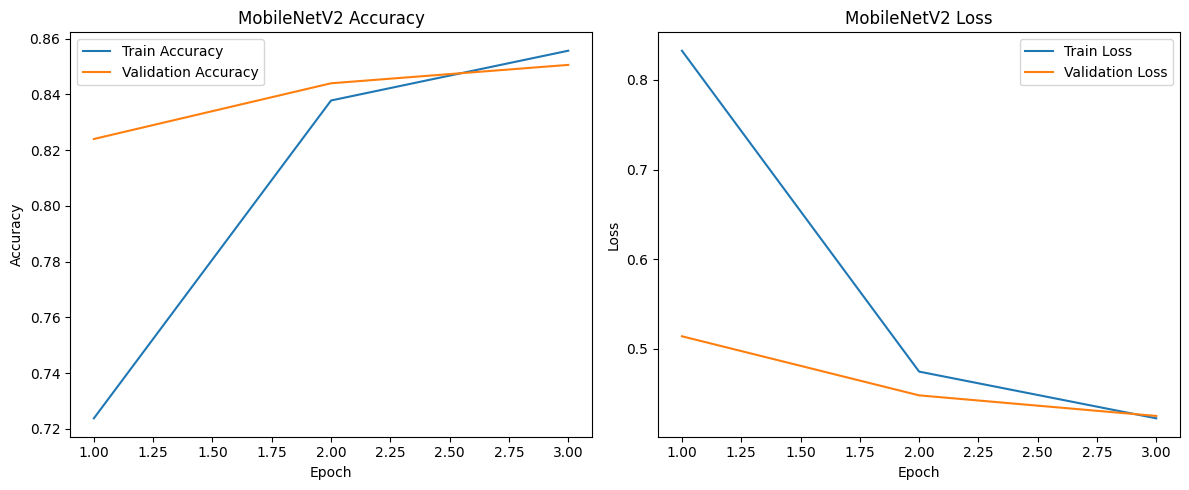

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
epochs_range = range(1,epochs+1)
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    mobilenet_history.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    epochs_range,
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    mobilenet_history.history["loss"],
    label="Train Loss"
)
plt.plot(
    epochs_range,
    mobilenet_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    x_test,
    y_test,
    batch_size=16,
    verbose=1
)

print(f"MobileNetV2 Test Loss:     {mobilenet_test_loss:.4f}")
print(
    f"MobileNetV2 Test Accuracy: "
    f"{mobilenet_test_accuracy * 100:.2f}%"
)

625/625 [==============================] - 8s 12ms/step - loss: 0.4412 - accuracy: 0.8450
MobileNetV2 Test Loss:     0.4412
MobileNetV2 Test Accuracy: 84.50%


In [45]:
import time

_ = mobilenet_model.predict(
    x_test[:48],
    batch_size=16,
    verbose=1
)

start_time = time.time()

mobilenet_predictions = mobilenet_model.predict(
    x_test,
    batch_size=16,
    verbose=1
)

end_time = time.time()

total_time = end_time - start_time
num_images = len(x_test)

ms_per_image = (total_time / num_images) * 1000
images_per_second = num_images / total_time

print(f"Total inference time: {total_time:.2f} seconds")
print(f"Time per image:       {ms_per_image:.2f} ms")
print(f"Throughput:            {images_per_second:.2f} images/sec")

625/625 [==============================] - 6s 10ms/step
Total inference time: 6.80 seconds
Time per image:       0.68 ms
Throughput:            1471.09 images/sec


In [46]:
total_weight_bytes = sum(
    weight.numpy().nbytes
    for weight in mobilenet_model.weights
)

mobilenet_weight_size_mb = total_weight_bytes / (1024 ** 2)

print(
    f"MobileNetV2 weight size: "
    f"{mobilenet_weight_size_mb:.2f} MB"
)

MobileNetV2 weight size: 8.66 MB


In [49]:
import os

mobilenet_weights_path = "mobilenet_v2_cifar10.weights.h5"

mobilenet_model.save_weights(mobilenet_weights_path)

mobilenet_weights_size_mb = (
    os.path.getsize(mobilenet_weights_path) / (1024 ** 2)
)

print(f"MobileNetV2 raw weight file size: {mobilenet_weights_size_mb:.2f} MB")

MobileNetV2 raw weight file size: 8.88 MB


| **Metric**                | **Exp 1 — ResNet50 Full Training** | **Exp 2 — ResNet50 Feature Extraction** | **Exp 3 — ResNet50 Fine-Tuning** | **Exp 4 — EfficientNetB0** | **Exp 5 — MobileNetV2** |
| ------------------------- | ---------------------------------: | --------------------------------------: | -------------------------------: | -------------------------: | ----------------------: |
| **Backbone**              |                           ResNet50 |                                ResNet50 |                         ResNet50 |             EfficientNetB0 |             MobileNetV2 |
| **Backbone state**        |                    Fully trainable |                            Fully frozen |         Last 30 layers trainable |                     Frozen |                  Frozen |
| **Trainable parameters**  |                         23,555,082 |                                  20,490 |                       14,470,666 |                     12,810 |                  12,810 |
| **Total parameters**      |                         23,608,202 |                              23,608,202 |                       23,608,202 |                  4,062,381 |               2,270,794 |
| **Test accuracy**         |                             87.47% |                                  84.93% |                           89.04% |                     84.03% |                  84.50% |
| **Test loss**             |                             0.4227 |                                  0.4522 |                           0.3351 |                     0.4852 |                  0.4412 |
| **Inference / 10k**       |                            14.95 s |                                 14.80 s |                          15.34 s |                     9.38 s |                  6.80 s |
| **Time / image**          |                            1.50 ms |                                 1.48 ms |                          1.53 ms |                    0.94 ms |                 0.68 ms |
| **Throughput**            |                       668.83 img/s |                            675.86 img/s |                     651.77 img/s |              1066.32 img/s |           1471.09 img/s |
| **Storage / weight size** |                         270.57 MB* |                               90.54 MB* |                       200.86 MB* |                  15.50 MB† |            **8.88 MB†** |


# 6. Experiment 6 - ConvNext

## 🧠 6.1 WHY CONVNEXT?

ConvNeXt is a modern pure CNN architecture designed by progressively modernizing ResNet using design ideas that became successful during the Vision Transformer era.

The goal is to understand:

> Can a CNN be modernized enough to compete with Transformer-based vision architectures?

In [50]:
convnext_base = keras.applications.ConvNeXtTiny(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
    pooling="avg"
)

print("ConvNeXt backbone loaded successfully.")

111650432/111650432 [==============================] - 23s 0us/step
ConvNeXt backbone loaded successfully.


In [51]:
convnext_base.trainable = False

print("Trainable:", convnext_base.trainable)

Trainable: False


In [52]:
inputs = keras.Input(shape=(32, 32, 3))

x = keras.layers.Resizing(96, 96)(inputs)

x = convnext_base(x)

outputs = keras.layers.Dense(
    10,
    activation="softmax"
)(x)

convnext_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ConvNeXtTiny_CIFAR10"
)

In [53]:
convnext_model.summary()

Model: "ConvNeXtTiny_CIFAR10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 resizing_5 (Resizing)       (None, 96, 96, 3)         0         
                                                                 
 convnext_tiny (Functional)  (None, 768)               27820128  
                                                                 
 dense_3 (Dense)             (None, 10)                7690      
                                                                 
Total params: 27,827,818
Trainable params: 7,690
Non-trainable params: 27,820,128
_________________________________________________________________


In [54]:
convnext_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [55]:
history_convnext = convnext_model.fit(
    x_train_split,
    y_train_split,
    validation_data=(x_val, y_val),
    epochs=3,
    batch_size=16,
    verbose=1
)

Epoch 1/3
2813/2813 [==============================] - 184s 62ms/step - loss: 0.7982 - accuracy: 0.7481 - val_loss: 0.4985 - val_accuracy: 0.8368
Epoch 2/3
2813/2813 [==============================] - 167s 59ms/step - loss: 0.4317 - accuracy: 0.8600 - val_loss: 0.4183 - val_accuracy: 0.8596
Epoch 3/3
2813/2813 [==============================] - 165s 59ms/step - loss: 0.3753 - accuracy: 0.8786 - val_loss: 0.3845 - val_accuracy: 0.8700


In [56]:
convnext_test_loss, convnext_test_accuracy = convnext_model.evaluate(
    x_test,
    y_test,
    batch_size=16,
    verbose=1
)

print("ConvNeXt Test Loss:", convnext_test_loss)
print("ConvNeXt Test Accuracy:", convnext_test_accuracy)

625/625 [==============================] - 34s 54ms/step - loss: 0.3993 - accuracy: 0.8679
ConvNeXt Test Loss: 0.39931461215019226
ConvNeXt Test Accuracy: 0.867900013923645


In [57]:
import time

start_time = time.time()

_ = convnext_model.predict(
    x_test,
    batch_size=16,
    verbose=0
)

end_time = time.time()

convnext_inference_time = end_time - start_time

convnext_ms_per_image = (
    convnext_inference_time / len(x_test)
) * 1000

convnext_throughput = (
    len(x_test) / convnext_inference_time
)

print(f"ConvNeXt inference time / 10k: {convnext_inference_time:.2f} s")
print(f"ConvNeXt time / image: {convnext_ms_per_image:.2f} ms")
print(f"ConvNeXt throughput: {convnext_throughput:.2f} img/s")

ConvNeXt inference time / 10k: 25.95 s
ConvNeXt time / image: 2.59 ms
ConvNeXt throughput: 385.36 img/s


In [58]:
import os

convnext_weights_path = "convnext_tiny_cifar10.weights.h5"

convnext_model.save_weights(convnext_weights_path)

convnext_weights_size_mb = (
    os.path.getsize(convnext_weights_path) / (1024 ** 2)
)

print(
    f"ConvNeXtTiny raw weight file size: "
    f"{convnext_weights_size_mb:.2f} MB"
)

ConvNeXtTiny raw weight file size: 106.36 MB


| **Metric**                | **Exp 1 — ResNet50 Full Training** | **Exp 2 — ResNet50 Feature Extraction** | **Exp 3 — ResNet50 Fine-Tuning** | **Exp 4 — EfficientNetB0** | **Exp 5 — MobileNetV2** | **Exp 6 — ConvNeXtTiny** |
| ------------------------- | ---------------------------------: | --------------------------------------: | -------------------------------: | -------------------------: | ----------------------: | -----------------------: |
| **Backbone**              |                           ResNet50 |                                ResNet50 |                         ResNet50 |             EfficientNetB0 |             MobileNetV2 |             ConvNeXtTiny |
| **Backbone state**        |                    Fully trainable |                            Fully frozen |         Last 30 layers trainable |                     Frozen |                  Frozen |                   Frozen |
| **Trainable parameters**  |                         23,555,082 |                                  20,490 |                       14,470,666 |                     12,810 |                  12,810 |                **7,690** |
| **Total parameters**      |                         23,608,202 |                              23,608,202 |                       23,608,202 |                  4,062,381 |               2,270,794 |           **27,827,818** |
| **Test accuracy**         |                             87.47% |                                  84.93% |                       **89.04%** |                     84.03% |                  84.50% |               **86.79%** |
| **Test loss**             |                             0.4227 |                                  0.4522 |                       **0.3351** |                     0.4852 |                  0.4412 |               **0.3993** |
| **Inference / 10k**       |                            14.95 s |                                 14.80 s |                          15.34 s |                     9.38 s |                  6.80 s |              **25.95 s** |
| **Time / image**          |                            1.50 ms |                                 1.48 ms |                          1.53 ms |                    0.94 ms |             **0.68 ms** |              **2.59 ms** |
| **Throughput**            |                       668.83 img/s |                            675.86 img/s |                     651.77 img/s |              1066.32 img/s |       **1471.09 img/s** |         **385.36 img/s** |
| **Storage / weight size** |                         270.57 MB* |                               90.54 MB* |                       200.86 MB* |              **15.50 MB†** |            **8.88 MB†** |           **106.36 MB†** |
